# Logistics Regression using ScikitLearn

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_redundant=0, random_state=42 )
X.shape, y.shape

((1000, 2), (1000,))

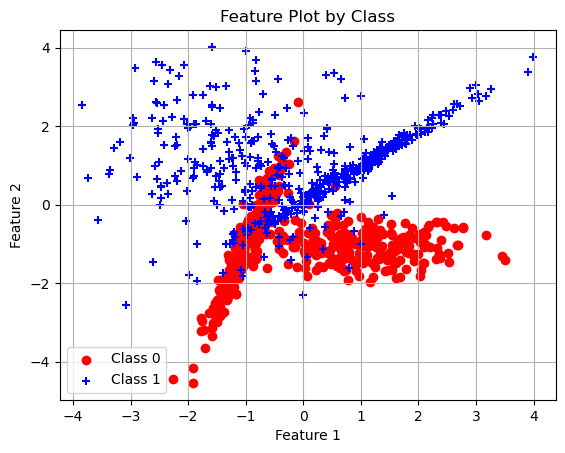

In [29]:
df = pd.DataFrame(X, columns=["X1", "X2"])
df["y"] = y

X_0 = df[df["y"] == 0]
X_1 = df[df["y"] == 1]

X_0_1 = X_0["X1"]
X_0_2 = X_0["X2"]

X_1_1 = X_1["X1"]
X_1_2 = X_1["X2"]

plt.scatter(X_0_1, X_0_2, color='red', marker='o', label='Class 0')
plt.scatter(X_1_1, X_1_2, color='blue', marker='+', label='Class 1')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Feature Plot by Class")
plt.legend()
plt.grid(True)
plt.show()


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Split your data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Initialize the model
model = LogisticRegression()

# 3. Train the model
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.875


In [31]:
model.predict_proba(np.array([[5, 6]])).max() >= 0.5

True

In [32]:
model.coef_, model.intercept_

(array([[-0.25811263,  2.14674757]]), array([0.23228973]))

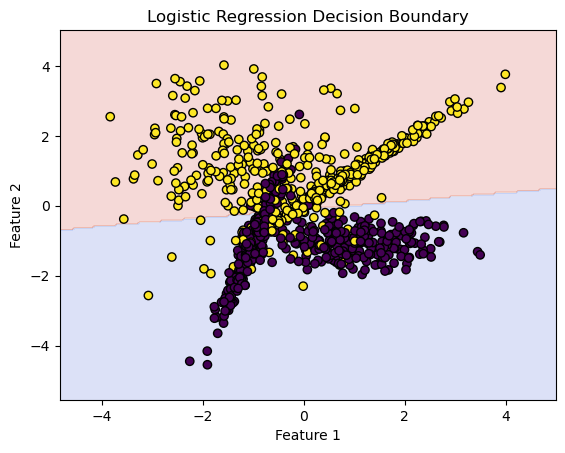

In [33]:
import numpy as np

# Create a mesh grid over feature space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]  # shape: (N, 2)

Z = model.predict(grid).reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

dummy_model_prob = [0 for _ in range(len(y_test))]
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1
dummy_model = roc_auc_score(y_test, dummy_model_prob)
model_auc = roc_auc_score(y_test, y_proba)
print(dummy_model, model_auc)

0.5 0.9279000000000001


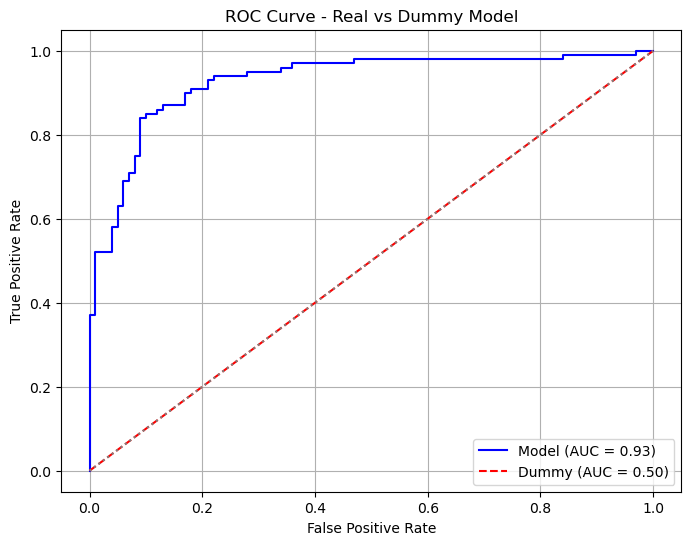

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_proba = model.predict_proba(X_test)[:, 1]  # Probability for class 1
dummy_model_prob = [0 for _ in range(len(y_test))]  # Dummy predicts class 0 always

# ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
fpr_dummy, tpr_dummy, thresholds_dummy = roc_curve(y_test, dummy_model_prob)

# AUC scores
model_auc = roc_auc_score(y_test, y_proba)
dummy_auc = roc_auc_score(y_test, dummy_model_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Model (AUC = {model_auc:.2f})", color='blue')
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC = {dummy_auc:.2f})", color='red', linestyle='--')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')  # Diagonal reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Real vs Dummy Model")
plt.legend()
plt.grid(True)
plt.show()


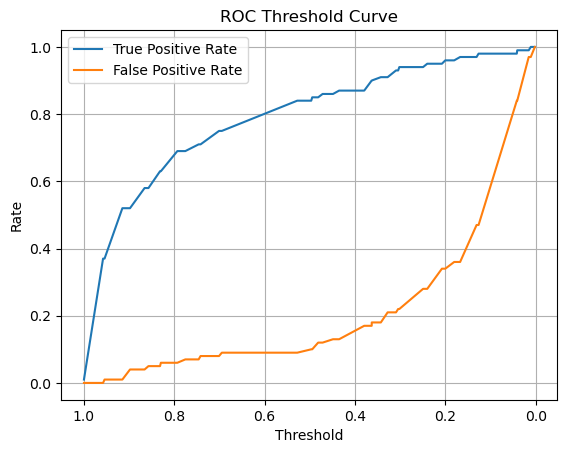

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')

plt.gca().invert_xaxis()  # 👈 Add this line

plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('ROC Threshold Curve')
plt.legend()
plt.grid(True)
plt.show()



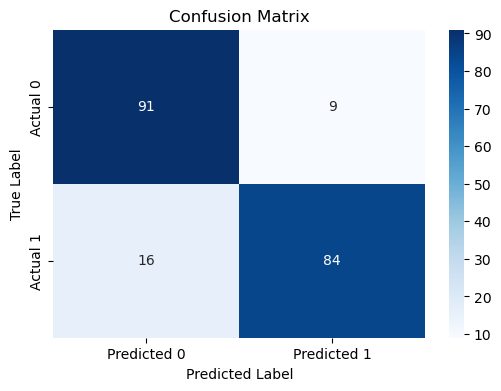

In [36]:
# 1. Generate the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Convert to DataFrame for labeled heatmap
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])

# 3. Plot using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [37]:
from sklearn.metrics import classification_report

# Predict labels (default threshold = 0.5)
y_pred = model.predict(X_test)

# Generate report
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.85      0.91      0.88       100
           1       0.90      0.84      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



In [38]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)  # default threshold = 0.5
cm = confusion_matrix(y_test, y_pred)

print(cm)


[[91  9]
 [16 84]]
